In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request
import os
import numpy as np

opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)')]
urllib.request.install_opener(opener)

os.makedirs('./data', exist_ok=True)
# Using reliable images from PyTorch examples
if not os.path.exists('./data/content.jpg'):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/pytorch/examples/master/fast_neural_style/images/content-images/amber.jpg", "./data/content.jpg")
if not os.path.exists('./data/style.jpg'):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/pytorch/examples/master/fast_neural_style/images/style-images/mosaic.jpg", "./data/style.jpg")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_image(img_path, max_size=400):
    image = Image.open(img_path).convert('RGB')
    size = max_size if max(image.size) > max_size else max(image.size)
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    image = transform(image)[:3, :, :].unsqueeze(0)
    return image.to(device)

def im_convert(tensor):
    image = tensor.cpu().clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1, 2, 0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)
    return image

content = load_image('./data/content.jpg')
style = load_image('./data/style.jpg')

vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
for param in vgg.parameters():
    param.requires_grad_(False)
vgg.to(device)

def get_features(image, model):
    layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '21': 'conv4_2',
        '28': 'conv5_1'
    }
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 80.3MB/s]


In [21]:
def gram_matrix(tensor):
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h * w)
    gram = torch.mm(tensor, tensor.t())
    return gram

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

style_weights = {'conv1_1': 1.,
                 'conv2_1': 0.75,
                 'conv3_1': 0.2,
                 'conv4_1': 0.2,
                 'conv5_1': 0.2}

content_weight = 1
style_weight = 1e6

In [22]:
target = content.clone().requires_grad_(True).to(device)
optimizer = optim.Adam([target], lr=0.003)

steps = 2000

for ii in range(1, steps + 1):
    target_features = get_features(target, vgg)

    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)

    style_loss = 0
    for layer in style_weights:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        _, d, h, w = target_feature.shape
        style_gram = style_grams[layer]
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram)**2)
        style_loss += layer_style_loss / (d * h * w)

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if ii % 500 == 0:
        print(f"Step {ii}, Total Loss: {total_loss.item():.4f}")

Step 500, Total Loss: 66234824.0000
Step 1000, Total Loss: 26263650.0000
Step 1500, Total Loss: 15699191.0000
Step 2000, Total Loss: 10627985.0000


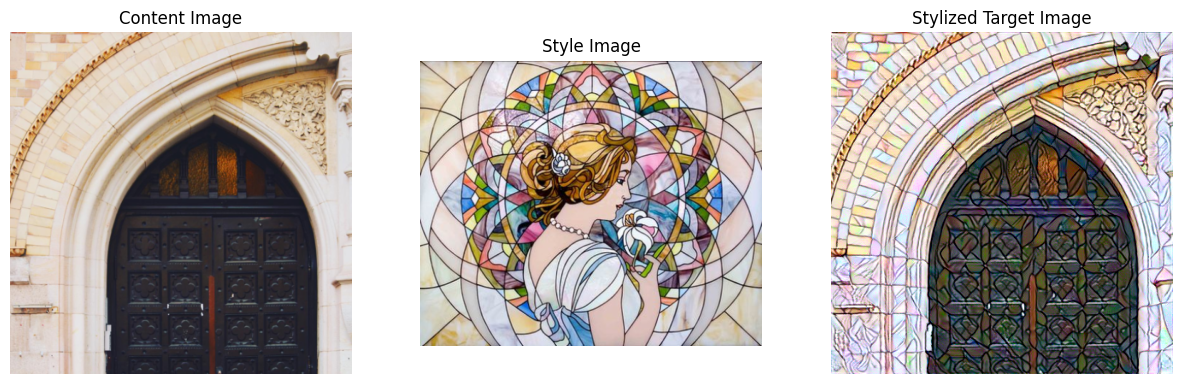

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.imshow(im_convert(content))
ax1.set_title("Content Image")
ax1.axis('off')

ax2.imshow(im_convert(style))
ax2.set_title("Style Image")
ax2.axis('off')

ax3.imshow(im_convert(target))
ax3.set_title("Stylized Target Image")
ax3.axis('off')

plt.show()